# RMSE vs Source Density

Sweep the number of sources from 1 to 20 and measure extraction RMSE over 10 independent trials per density using the Phase 1 `SciPySparseOperator` + `SpectralSolver` pipeline.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import spectrex
from spectrex import (
    EigenspectraBasis,
    InstrumentConfig,
    NoiseModel,
    SciPySparseOperator,
    SpectralSolver,
)

warnings.filterwarnings('ignore')

# Paths — notebook assumed to live in notebooks/ inside the repo root
NOTEBOOK_DIR = Path.cwd()
REPO = NOTEBOOK_DIR.parent
TESTDATA = REPO / 'testdata'
CACHE_PATH = NOTEBOOK_DIR / 'analysis_operator_cache.npz'
COLD_START = not CACHE_PATH.exists()
print(f'spectrex version: {spectrex.__version__}')
print(f'Cold start: {COLD_START}')

spectrex version: 0.1.1.dev12+g3edffcafc.d20260505
Cold start: True


## 1. Build or Load Operator

In [2]:
config = InstrumentConfig.from_files(
    conf_path=TESTDATA / 'Config Files' / 'GR150R.F150W.220725.conf',
    wavelengthrange_path=TESTDATA / 'jwst_niriss_wavelengthrange_0002.asdf',
    sensitivity_dir=TESTDATA / 'SenseConfig' / 'wfss-grism-configuration',
    filter_name='F150W',
    n_wavelengths=150,
)
basis = EigenspectraBasis.from_csv(
    TESTDATA / 'eigenspectra_kurucz.csv',
    config.wavelengths,
)

IMAGE_SHAPE = (50, 20)

if COLD_START:
    print('Building operator (cold start)…')
    op = SciPySparseOperator.build(config, basis, IMAGE_SHAPE)
    op.save(CACHE_PATH)
    print(f'Saved to {CACHE_PATH}')
else:
    print('Loading cached operator…')
    op = SciPySparseOperator.load(CACHE_PATH)
    print('Done.')

n_pix = IMAGE_SHAPE[0] * IMAGE_SHAPE[1]
n_comp = basis.n_components
print(f'Image shape: {IMAGE_SHAPE}')
print(f'n_coefficients: {op.n_coefficients}, n_components: {n_comp}')

Building operator (cold start)…


Saved to /Users/fouesneau/Work/projects/the-bagel-org/spectrex/.worktrees/analysis-rmse/notebooks/analysis_operator_cache.npz
Image shape: (50, 20)
n_coefficients: 10000, n_components: 10


## 2. Pipeline Helper

In [3]:
def run_pipeline(
    op: SciPySparseOperator,
    basis: EigenspectraBasis,
    image_shape: tuple[int, int],
    source_pixels: list[int],
    rng: np.random.Generator,
    noise_model: NoiseModel,
    regularisation: float = 1e-2,
) -> dict:
    """Run one mock extraction trial for the given source pixel positions.

    Parameters
    ----------
    op : SciPySparseOperator
        Pre-built forward operator for the full image.
    basis : EigenspectraBasis
        Eigenspectra basis (used for n_components only).
    image_shape : tuple[int, int]
        ``(n_rows, n_cols)``.
    source_pixels : list[int]
        Flat pixel indices (row * n_cols + col) for each active source.
    rng : np.random.Generator
        NumPy random generator.
    noise_model : NoiseModel
        Noise model for mock observations and solve weighting.
    regularisation : float
        Tikhonov regularisation λ. Default 1e-2.

    Returns
    -------
    dict
        Keys: ``rmse``, ``n_sources``, ``a_true``, ``a_rec``.
    """
    n_pix_ = image_shape[0] * image_shape[1]
    n_comp_ = basis.n_components

    # True coefficients: non-zero only at source pixel blocks
    a_true = np.zeros(n_pix_ * n_comp_)
    for p in source_pixels:
        a_true[p * n_comp_ : (p + 1) * n_comp_] = rng.standard_normal(n_comp_)

    # Forward model → noisy observation
    f_clean = op.apply(a_true).reshape(image_shape)
    f_noisy = noise_model.sample(f_clean, rng)

    # Support mask: True at coefficient blocks of active sources
    mask = np.zeros(n_pix_ * n_comp_, dtype=bool)
    for p in source_pixels:
        mask[p * n_comp_ : (p + 1) * n_comp_] = True

    # Solve
    solver = SpectralSolver(
        op, noise_model=noise_model, regularisation=regularisation
    )
    a_rec = solver.solve(f_noisy, support_mask=mask)

    # RMSE on active sources only
    rmse = float(np.sqrt(np.mean((a_rec[mask] - a_true[mask]) ** 2)))
    return {
        'rmse': rmse,
        'n_sources': len(source_pixels),
        'a_true': a_true,
        'a_rec': a_rec,
    }

## 3. Density Sweep

In [4]:
N_SOURCES_GRID = [1, 2, 3, 5, 8, 10, 15, 20]
N_TRIALS = 10
REGULARISATION = 1e-2
NOISE_MODEL = NoiseModel(read_noise=5.0)
MASTER_RNG = np.random.default_rng(2026)

In [5]:
results: dict[int, list[float]] = {n: [] for n in N_SOURCES_GRID}

for n_src in N_SOURCES_GRID:
    for trial in range(N_TRIALS):
        rng = np.random.default_rng(MASTER_RNG.integers(0, 2**31))
        source_pixels = rng.choice(n_pix, size=n_src, replace=False).tolist()
        res = run_pipeline(
            op, basis, IMAGE_SHAPE, source_pixels, rng,
            NOISE_MODEL, REGULARISATION,
        )
        results[n_src].append(res['rmse'])
    mean_ = np.mean(results[n_src])
    std_ = np.std(results[n_src])
    print(f'n_sources={n_src:3d}: mean RMSE = {mean_:.4f} ± {std_:.4f}')

n_sources=  1: mean RMSE = 0.9654 ± 0.1987
n_sources=  2: mean RMSE = 1.0241 ± 0.1583
n_sources=  3: mean RMSE = 0.8958 ± 0.0714
n_sources=  5: mean RMSE = 0.9641 ± 0.0747
n_sources=  8: mean RMSE = 1.0352 ± 0.0420
n_sources= 10: mean RMSE = 1.0024 ± 0.0906
n_sources= 15: mean RMSE = 1.0120 ± 0.0368
n_sources= 20: mean RMSE = 0.9940 ± 0.0383


## 4. Results

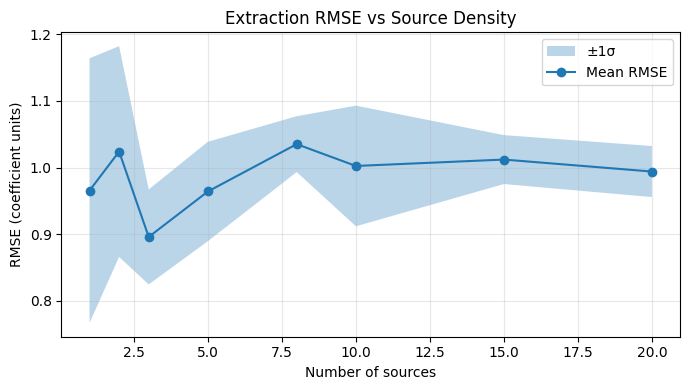

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))

ns_arr = np.array(N_SOURCES_GRID)
means = np.array([np.mean(results[n]) for n in N_SOURCES_GRID])
stds  = np.array([np.std(results[n])  for n in N_SOURCES_GRID])

ax.fill_between(ns_arr, means - stds, means + stds,
                alpha=0.3, label='±1σ')
ax.plot(ns_arr, means, 'o-', label='Mean RMSE')
ax.set_xlabel('Number of sources')
ax.set_ylabel('RMSE (coefficient units)')
ax.set_title('Extraction RMSE vs Source Density')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Observations

*(Fill in after executing the notebook.)*

- Expected: RMSE rises with source density as trace overlap increases.
- At low density (1–3 sources), the problem is well-conditioned and RMSE should be near the noise floor.
- The regularisation parameter `λ = 1e-2` is held fixed; a separate λ-sweep is left as a follow-up.